In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
from evaluation.metrics import (
    case_level_metrics,
    per_task_metrics,
    compute_span_level_metrics,
    bootstrap_confidence_interval,
    compute_confusion_matrix,
    compute_classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1. Dataset Preparation and Statistics

### RAGTruth Dataset Overview

- **Total Records:** 17,617 LLM-generated responses with word-level hallucination annotations
- **Tasks:** Question Answering (MS MARCO), Summarization (CNN/DailyMail), Data-to-Text (Yelp)
- **LLMs:** GPT-4, ChatGPT, Llama-2 (7B, 13B, 70B), Mistral-7B
- **Annotation:** Human-annotated hallucination spans with 4 label types

In [2]:
def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return records

train_data = load_jsonl("RAGTruth/baseline/train.jsonl")
dev_data = load_jsonl("RAGTruth/baseline/dev.jsonl")
test_data = load_jsonl("RAGTruth/baseline/test.jsonl")

print(f"Training set: {len(train_data)} records")
print(f"Development set: {len(dev_data)} records")
print(f"Test set: {len(test_data)} records")
print(f"Total: {len(train_data) + len(dev_data) + len(test_data)} records")

Training set: 14047 records
Development set: 895 records
Test set: 2675 records
Total: 17617 records


### Data Split Strategy

In [3]:
split_df = pd.DataFrame([
    {'Split': 'Training', 'Size': len(train_data), 'Percentage': f"{len(train_data)/(len(train_data)+len(dev_data)+len(test_data))*100:.1f}%", 'Purpose': 'Fine-tuning'},
    {'Split': 'Development', 'Size': len(dev_data), 'Percentage': f"{len(dev_data)/(len(train_data)+len(dev_data)+len(test_data))*100:.1f}%", 'Purpose': '50 source IDs per task'},
    {'Split': 'Test', 'Size': len(test_data), 'Percentage': f"{len(test_data)/(len(train_data)+len(dev_data)+len(test_data))*100:.1f}%", 'Purpose': 'Held-out evaluation'}
])
print(split_df.to_string(index=False))

      Split  Size Percentage                Purpose
   Training 14047      79.7%            Fine-tuning
Development   895       5.1% 50 source IDs per task
       Test  2675      15.2%    Held-out evaluation


### Task Distribution

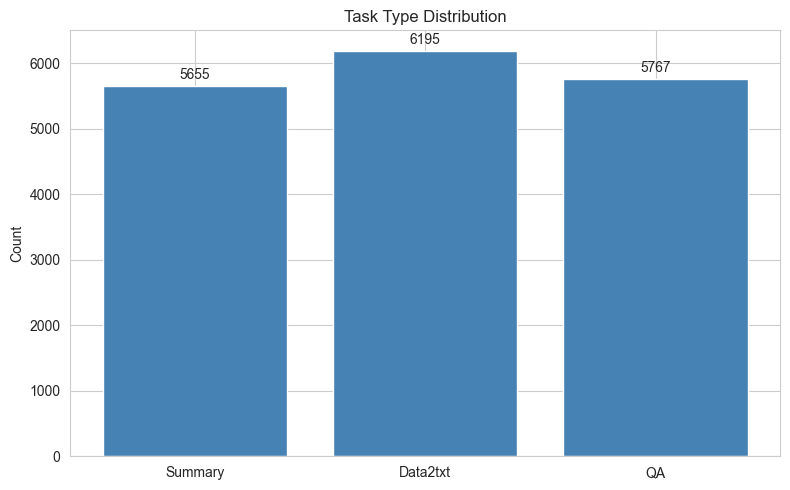


Task Distribution:
  Summary: 5655 (32.1%)
  Data2txt: 6195 (35.2%)
  QA: 5767 (32.7%)


In [4]:
all_data = train_data + dev_data + test_data
task_counts = Counter([r['task_type'] for r in all_data])

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(task_counts.keys(), task_counts.values(), color='steelblue')
ax.set_ylabel('Count')
ax.set_title('Task Type Distribution')
for i, (k, v) in enumerate(task_counts.items()):
    ax.text(i, v + 100, str(v), ha='center')
plt.tight_layout()
plt.show()

print("\nTask Distribution:")
for task, count in task_counts.items():
    print(f"  {task}: {count} ({count/len(all_data)*100:.1f}%)")

### Hallucination Rates by Task

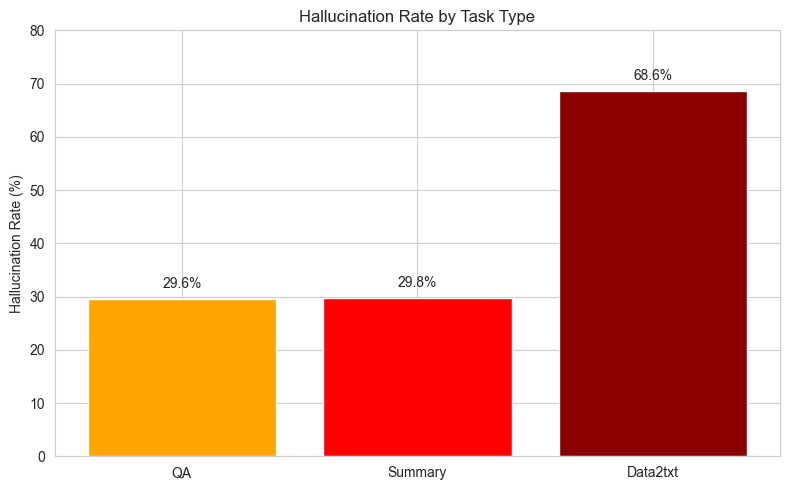


Hallucination Rates:
  Data2txt: 68.6%
  Summary: 29.8%
  QA: 29.6%


In [5]:
halluc_rates = {}
for task in ['QA', 'Summary', 'Data2txt']:
    task_records = [r for r in all_data if r['task_type'] == task]
    halluc_count = sum(1 for r in task_records if len(r.get('labels', [])) > 0)
    halluc_rates[task] = halluc_count / len(task_records) * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(halluc_rates.keys(), halluc_rates.values(), color=['orange', 'red', 'darkred'])
ax.set_ylabel('Hallucination Rate (%)')
ax.set_title('Hallucination Rate by Task Type')
ax.set_ylim(0, 80)
for i, (k, v) in enumerate(halluc_rates.items()):
    ax.text(i, v + 2, f"{v:.1f}%", ha='center')
plt.tight_layout()
plt.show()

print("\nHallucination Rates:")
for task, rate in sorted(halluc_rates.items(), key=lambda x: x[1], reverse=True):
    print(f"  {task}: {rate:.1f}%")

## 2. Evaluation Protocol

### Metrics

**Track A (Hallucination Detection):**
- Case-level F1 (primary): Binary classification
- Case-level Precision/Recall: Per task type
- Span-level F1: Character-overlap between predicted and gold spans
- Bootstrap 95% CI: Statistical validation

**Track B (RAG QA):**
- Answerable Rate: Percentage of questions the system can answer
- Answer Length: Distribution of answer word counts

### Baseline Designs

In [6]:
baseline_table = pd.DataFrame([
    {'Track': 'A', 'Baseline': 'RAGTruth LLaMA-2-13B', 'Method': 'Fine-tuned on train split to output hallucination span list', 'Type': 'Supervised fine-tuning', 'Reference': 'Wu et al., 2023'},
    {'Track': 'A', 'Baseline': 'Self-Verification (GPT-4o-mini)', 'Method': 'LLM prompted to check output against source passages', 'Type': 'Inference-time, zero-shot', 'Reference': 'Manakul et al., 2023'},
    {'Track': 'A', 'Baseline': 'Multi-Agent Pipeline (proposed)', 'Method': 'GPT claim extractor + DeBERTa NLI verifier + rule aggregator', 'Type': 'Inference-time, no training', 'Reference': 'CKPT3'},
    {'Track': 'B', 'Baseline': 'RAG System (GPT-4o-mini)', 'Method': 'Generate answers from pre-retrieved passages', 'Type': 'Inference-time, zero-shot', 'Reference': 'This work'}
])
print(baseline_table.to_string(index=False))

Track                        Baseline                                                       Method                        Type            Reference
    A            RAGTruth LLaMA-2-13B  Fine-tuned on train split to output hallucination span list      Supervised fine-tuning      Wu et al., 2023
    A Self-Verification (GPT-4o-mini)         LLM prompted to check output against source passages   Inference-time, zero-shot Manakul et al., 2023
    A Multi-Agent Pipeline (proposed) GPT claim extractor + DeBERTa NLI verifier + rule aggregator Inference-time, no training                CKPT3
    B        RAG System (GPT-4o-mini)                 Generate answers from pre-retrieved passages   Inference-time, zero-shot            This work


---

## 3. Baseline Results

### Track A: Hallucination Detection

#### Self-Verification Baseline (GPT-4o-mini)

**Method:** Zero-shot prompting where GPT-4o-mini identifies hallucinated spans by comparing LLM responses against source passages.

**Evaluation:** 600 test samples (200 per task, balanced)

**Ground Truth:** Human-annotated hallucination spans from RAGTruth dataset

In [7]:
gpt_predictions = load_jsonl("results/gpt_baseline_predictions.jsonl")
print(f"Total predictions: {len(gpt_predictions)}")
print(f"Task distribution: {Counter([r['task_type'] for r in gpt_predictions])}")

Total predictions: 600
Task distribution: Counter({'QA': 200, 'Summary': 200, 'Data2txt': 200})


#### Case-Level Performance

In [8]:
case_metrics = case_level_metrics(gpt_predictions)
task_metrics = per_task_metrics(gpt_predictions)

print("Overall Case-Level Performance:")
print(f"  Precision: {case_metrics['precision']:.4f}")
print(f"  Recall:    {case_metrics['recall']:.4f}")
print(f"  F1 Score:  {case_metrics['f1']:.4f}")
print(f"  Samples:   {case_metrics['n_samples']}")

print("\nPer-Task Breakdown:")
for task in ['QA', 'Summary', 'Data2txt']:
    m = task_metrics[task]
    print(f"  {task:<10} -> P: {m['precision']:.4f}  R: {m['recall']:.4f}  F1: {m['f1']:.4f}  (n={m['n_samples']})")

Overall Case-Level Performance:
  Precision: 0.6189
  Recall:    0.7523
  F1 Score:  0.6791
  Samples:   600

Per-Task Breakdown:
  QA         -> P: 0.4510  R: 0.6571  F1: 0.5349  (n=200)
  Summary    -> P: 0.3837  R: 0.6471  F1: 0.4818  (n=200)
  Data2txt   -> P: 0.8438  R: 0.8182  F1: 0.8308  (n=200)


#### Statistical Validation: Bootstrap Confidence Intervals

95% Bootstrap Confidence Interval:
  Mean F1:   0.6790
  CI:        [0.6275, 0.7240]
  Width:     0.0965


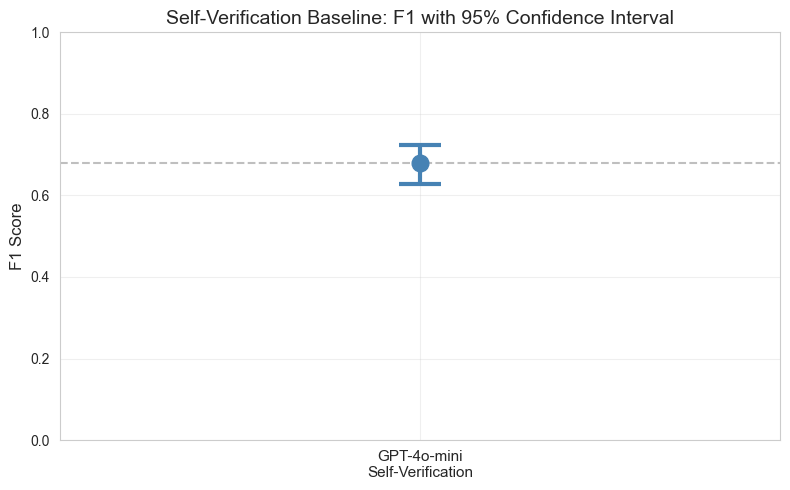

In [9]:
bootstrap_ci = bootstrap_confidence_interval(gpt_predictions, n_iterations=1000, confidence=0.95)

print("95% Bootstrap Confidence Interval:")
print(f"  Mean F1:   {bootstrap_ci['mean_f1']:.4f}")
print(f"  CI:        [{bootstrap_ci['ci_lower']:.4f}, {bootstrap_ci['ci_upper']:.4f}]")
print(f"  Width:     {bootstrap_ci['ci_upper'] - bootstrap_ci['ci_lower']:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar([0], [bootstrap_ci['mean_f1']], 
            yerr=[[bootstrap_ci['mean_f1'] - bootstrap_ci['ci_lower']], 
                  [bootstrap_ci['ci_upper'] - bootstrap_ci['mean_f1']]],
            fmt='o', markersize=12, capsize=15, capthick=3, linewidth=3, color='steelblue')
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(0, 1)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Self-Verification Baseline: F1 with 95% Confidence Interval', fontsize=14)
ax.set_xticks([0])
ax.set_xticklabels(['GPT-4o-mini\nSelf-Verification'], fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=bootstrap_ci['mean_f1'], color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Visualization: Performance by Task Type

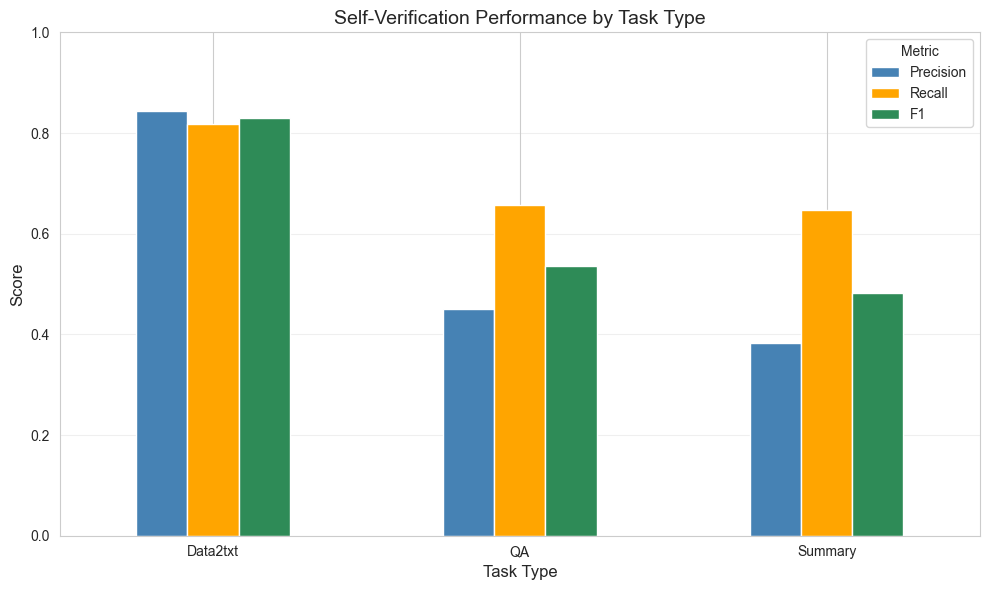

In [10]:
task_df = pd.DataFrame([
    {'Task': task, 'Metric': 'Precision', 'Score': m['precision']} for task, m in task_metrics.items()
] + [
    {'Task': task, 'Metric': 'Recall', 'Score': m['recall']} for task, m in task_metrics.items()
] + [
    {'Task': task, 'Metric': 'F1', 'Score': m['f1']} for task, m in task_metrics.items()
])

fig, ax = plt.subplots(figsize=(10, 6))
task_pivot = task_df.pivot(index='Task', columns='Metric', values='Score')
task_pivot[['Precision', 'Recall', 'F1']].plot(kind='bar', ax=ax, color=['steelblue', 'orange', 'seagreen'])
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Task Type', fontsize=12)
ax.set_title('Self-Verification Performance by Task Type', fontsize=14)
ax.set_ylim(0, 1)
ax.legend(title='Metric', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Span-Level Metrics

In [11]:
span_metrics = compute_span_level_metrics(gpt_predictions)

print("Overall Span-Level Performance:")
print(f"  Mean F1:   {span_metrics['mean_span_f1']:.4f}")
print(f"  Median F1: {span_metrics['median_span_f1']:.4f}")
print(f"  Std F1:    {span_metrics['std_span_f1']:.4f}")

print("\nPer-Task Span-Level F1:")
for task in ['QA', 'Summary', 'Data2txt']:
    task_records = [r for r in gpt_predictions if r['task_type'] == task]
    task_span = compute_span_level_metrics(task_records)
    print(f"  {task:<10} {task_span['mean_span_f1']:.4f}")

Overall Span-Level Performance:
  Mean F1:   0.5709
  Median F1: 0.7676
  Std F1:    0.4554

Per-Task Span-Level F1:
  QA         0.7423
  Summary    0.5286
  Data2txt   0.4420


#### Confusion Matrix

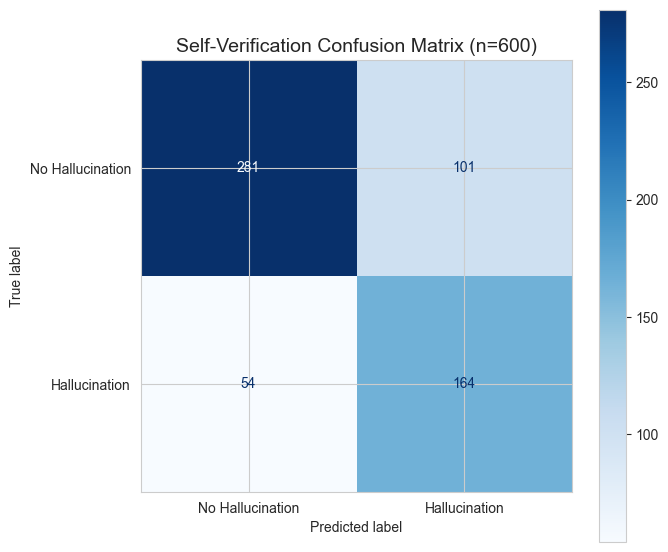


Accuracy: 0.7417
True Negatives:  281
False Positives: 101
False Negatives: 54
True Positives:  164


In [12]:
cm = compute_confusion_matrix(gpt_predictions)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=['No Hallucination', 'Hallucination'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Self-Verification Confusion Matrix (n=600)', fontsize=14)
plt.tight_layout()
plt.show()

accuracy = (cm[0][0] + cm[1][1]) / cm.sum()
print(f"\nAccuracy: {accuracy:.4f}")
print(f"True Negatives:  {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives:  {cm[1][1]}")

#### Classification Report

In [13]:
class_report = compute_classification_report(gpt_predictions)
print(class_report)

                  precision    recall  f1-score   support

No Hallucination       0.84      0.74      0.78       382
   Hallucination       0.62      0.75      0.68       218

        accuracy                           0.74       600
       macro avg       0.73      0.74      0.73       600
    weighted avg       0.76      0.74      0.75       600



---

### Track B: RAG QA Performance (Supplementary)

#### RAG System Baseline (GPT-4o-mini Generator)


In [14]:
rag_results = load_jsonl("baselines/rag_baseline_answers.jsonl")
print(f"Total QA pairs evaluated: {len(rag_results)}")

Total QA pairs evaluated: 100


#### Answer Quality Metrics

In [15]:
def categorize_answer(answer):
    answer_lower = answer.lower()
    if 'cannot answer' in answer_lower or 'not enough information' in answer_lower:
        return 'Cannot Answer'
    elif len(answer.split()) < 5:
        return 'Very Short'
    elif len(answer.split()) < 20:
        return 'Short'
    elif len(answer.split()) < 50:
        return 'Medium'
    else:
        return 'Long'

categories = [categorize_answer(r['generated_answer']) for r in rag_results]
category_counts = Counter(categories)

print("Answer Length Distribution:")
for cat, count in category_counts.most_common():
    print(f"  {cat}: {count} ({count/len(rag_results)*100:.1f}%)")

answerable_rate = (len(rag_results) - category_counts.get('Cannot Answer', 0)) / len(rag_results)
print(f"\nAnswerable Rate: {answerable_rate*100:.1f}%")

Answer Length Distribution:
  Long: 70 (70.0%)
  Medium: 20 (20.0%)
  Cannot Answer: 10 (10.0%)

Answerable Rate: 90.0%


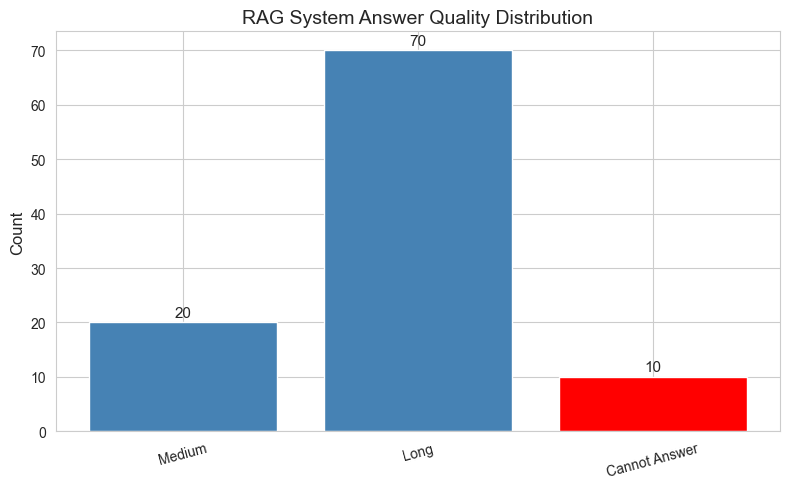

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
cats = list(category_counts.keys())
vals = list(category_counts.values())
colors = ['red' if c == 'Cannot Answer' else 'steelblue' for c in cats]
ax.bar(cats, vals, color=colors)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('RAG System Answer Quality Distribution', fontsize=14)
for i, v in enumerate(vals):
    ax.text(i, v + 1, str(v), ha='center', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#### Word Count Statistics

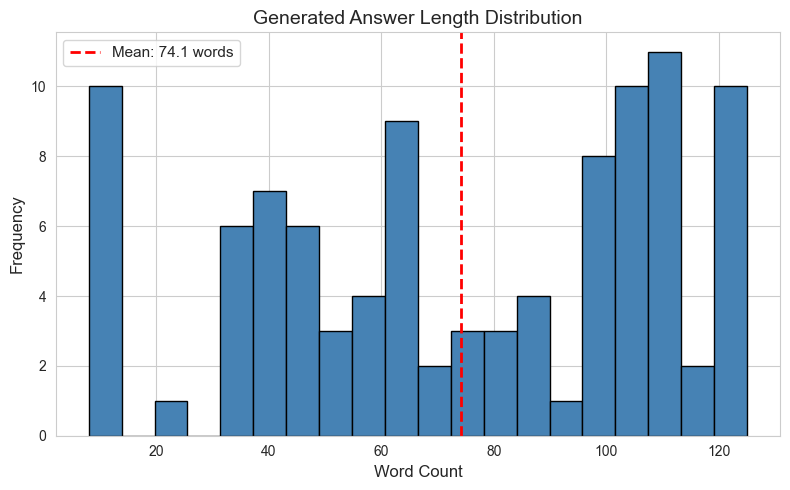

Average answer length: 74.1 words
Min: 8 words
Max: 125 words


In [17]:
word_counts = [len(r['generated_answer'].split()) for r in rag_results]
avg_words = sum(word_counts) / len(word_counts)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(word_counts, bins=20, color='steelblue', edgecolor='black')
ax.axvline(avg_words, color='red', linestyle='--', linewidth=2, label=f'Mean: {avg_words:.1f} words')
ax.set_xlabel('Word Count', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Generated Answer Length Distribution', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Average answer length: {avg_words:.1f} words")
print(f"Min: {min(word_counts)} words")
print(f"Max: {max(word_counts)} words")

---

## 4. Summary Statistics

### Track A: Hallucination Detection Results

In [18]:
track_a_summary = pd.DataFrame([
    {'Metric': 'Overall F1', 'Value': f"{case_metrics['f1']:.4f}"},
    {'Metric': '95% CI', 'Value': f"[{bootstrap_ci['ci_lower']:.4f}, {bootstrap_ci['ci_upper']:.4f}]"},
    {'Metric': 'Accuracy', 'Value': f"{accuracy:.4f}"},
    {'Metric': 'Sample Size', 'Value': f"{case_metrics['n_samples']}"},
    {'Metric': 'Best Task (Data2txt F1)', 'Value': f"{task_metrics['Data2txt']['f1']:.4f}"},
    {'Metric': 'Worst Task (Summary F1)', 'Value': f"{task_metrics['Summary']['f1']:.4f}"},
    {'Metric': 'Mean Span-Level F1', 'Value': f"{span_metrics['mean_span_f1']:.4f}"},
])
print("Track A: Self-Verification Baseline (Hallucination Detection)")
print(track_a_summary.to_string(index=False))

print("\n" + "="*60)

track_b_summary = pd.DataFrame([
    {'Metric': 'Answerable Rate', 'Value': f"{answerable_rate*100:.1f}%"},
    {'Metric': 'Avg Answer Length', 'Value': f"{avg_words:.1f} words"},
    {'Metric': 'Cannot Answer Rate', 'Value': f"{(1-answerable_rate)*100:.1f}%"},
    {'Metric': 'Sample Size', 'Value': f"{len(rag_results)}"},
])
print("\nTrack B: RAG System Baseline (QA Generation)")
print(track_b_summary.to_string(index=False))

Track A: Self-Verification Baseline (Hallucination Detection)
                 Metric            Value
             Overall F1           0.6791
                 95% CI [0.6275, 0.7240]
               Accuracy           0.7417
            Sample Size              600
Best Task (Data2txt F1)           0.8308
Worst Task (Summary F1)           0.4818
     Mean Span-Level F1           0.5709


Track B: RAG System Baseline (QA Generation)
            Metric      Value
   Answerable Rate      90.0%
 Avg Answer Length 74.1 words
Cannot Answer Rate      10.0%
       Sample Size        100
